# Clinical Trial Success Prediction Using Phase
In contrast to the other model that uses completion as the success metric, this notebook shows the model training when the phase is used as the metric. 

In [1]:
# Load libraries needed for data IO and wrangling
import json
from pathlib import Path
import pandas as pd

# Read the NDJSON export (one trial per line) into a DataFrame
DATA_PATH = Path('raw_data/trials_summary.ndjson')
assert DATA_PATH.exists(), f'{DATA_PATH} not found'
df = pd.read_json(DATA_PATH, lines=True)

# Quick peek to confirm the schema loaded as expected
df.head()

,xml_path,nct_id,org_study_id,brief_title,official_title,overall_status,why_stopped,phase,study_type,lead_sponsor,...,conditions,condition_mesh_terms,keywords,interventions,intervention_mesh_terms,primary_outcomes,secondary_outcomes,number_of_arms,number_of_groups,locations
0,raw_data/NCT0000xxxx/NCT00000233.xml,NCT00000233,NIDA-06969-15,"Alternate Day Buprenorphine Administration, Ph...","Alternate Day Buprenorphine Administration, Ph...",Completed,,Phase 2,Interventional,National Institute on Drug Abuse (NIDA),...,[Opioid-Related Disorders],[Opioid-Related Disorders],[],"[{'type': 'Drug', 'name': 'Buprenorphine', 'de...",[Buprenorphine],"[Opioid withdrawal, Subjective dose estimate, ...",[],,,"{'facility_count': 1, 'countries': ['United St..."
1,raw_data/NCT0000xxxx/NCT00004055.xml,NCT00004055,NCCTG-982052,"Topotecan, Paclitaxel, and Filgrastim in Treat...",Phase II Trial of Oral Topotecan and Paclitaxe...,Completed,,Phase 2,Interventional,Alliance for Clinical Trials in Oncology,...,[Lung Cancer],[Lung Neoplasms],[extensive stage small cell lung cancer],"[{'type': 'Biological', 'name': 'filgrastim', ...","[Filgrastim, Paclitaxel, Topotecan]",[response rate],[survival],1,,"{'facility_count': 19, 'countries': ['United S..."
2,raw_data/NCT0000xxxx/NCT00002424.xml,NCT00002424,300B,A Study to Compare the Safety and Effectivenes...,"A Multicenter, Double-Blind, Randomized Pilot ...",Suspended,,Phase 2,Interventional,Merck Sharp & Dohme LLC,...,[HIV Infections],[HIV Infections],"[Drug Therapy, Combination, Drug Administratio...","[{'type': 'Drug', 'name': 'L-756423', 'descrip...","[L 756423, Indinavir, Lamivudine, Stavudine]",[],[],,,"{'facility_count': 16, 'countries': ['United S..."
3,raw_data/NCT0000xxxx/NCT00002342.xml,NCT00002342,088C,A Study of Tecogalan Sodium,A Phase I Trial of Tecogalan Sodium (DS-4152) ...,Completed,,Phase 1,Interventional,Daiichi Pharmaceuticals,...,"[Sarcoma, Kaposi, HIV Infections]","[Sarcoma, Kaposi, HIV Infections, Neoplasms, A...","[Neoplasms, Sarcoma, Kaposi, Acquired Immunode...","[{'type': 'Drug', 'name': 'Tecogalan sodium', ...",[tecogalan],[],[],,,"{'facility_count': 1, 'countries': ['United St..."
4,raw_data/NCT0000xxxx/NCT00004733.xml,NCT00004733,R01NS034796,Timing of Levodopa Treatment in Parkinson's Di...,Earlier Versus Later L-Dopa in Parkinson's Dis...,Completed,,Phase 3,Interventional,National Institute of Neurological Disorders a...,...,[Parkinson's Disease],"[Parkinson Disease, Tremor]","[Parkinson's, ELLDOPA, L-dopa, levodopa, Sinem...","[{'type': 'Drug', 'name': 'levodopa', 'descrip...",[Levodopa],[],[],,,"{'facility_count': 1, 'countries': ['United St..."


In [17]:
# Convert the most useful date columns into pandas datetime objects
DATE_COLS = [
    "study_first_posted",
    "last_update_posted",
    "start_date",
    "completion_date",
    "primary_completion_date",
]
for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df[DATE_COLS].head()


,study_first_posted,last_update_posted,start_date,completion_date,primary_completion_date
0,1999-09-21,2005-08-17,1993-05-01,NaT,NaT
1,2004-06-03,2016-07-13,1999-11-01,2004-07-01,2004-07-01
2,2001-08-31,2005-06-24,NaT,NaT,NaT
3,2001-08-31,2005-06-24,NaT,NaT,NaT
4,2000-02-28,2005-06-24,1998-01-01,2004-02-01,NaT


In [18]:
import re
import numpy as np

# Convert textual age expressions ("18 Years", "6 Months") into numeric years
AGE_PATTERN = re.compile(r"(\d+)")


def _age_to_years(value):
    if pd.isna(value) or value in ("", "N/A"):
        return np.nan
    text = str(value)
    match = AGE_PATTERN.search(text)
    if not match:
        return np.nan
    number = float(match.group(1))
    text_lower = text.lower()
    if "month" in text_lower:
        return number / 12
    if "week" in text_lower:
        return number / 52
    if "day" in text_lower:
        return number / 365
    return number


df["minimum_age_years"] = df["minimum_age"].apply(_age_to_years)
df["maximum_age_years"] = df["maximum_age"].apply(_age_to_years)

# Enrollment counts sometimes come as strings; coerce to numeric
df["enrollment_num"] = pd.to_numeric(df["enrollment"], errors="coerce")

# Pull facility counts out of the nested `locations` dict

def _extract_facility_count(value):
    if isinstance(value, dict):
        return value.get("facility_count")
    return np.nan


df["facility_count"] = df["locations"].apply(_extract_facility_count)

# Track how many conditions are listed per trial

df["conditions_count"] = df["conditions"].apply(lambda x: len(x) if isinstance(x, list) else 0)

df[[
    "minimum_age_years",
    "maximum_age_years",
    "enrollment_num",
    "facility_count",
    "conditions_count",
]].head()


,minimum_age_years,maximum_age_years,enrollment_num,facility_count,conditions_count
0,34.0,51.0,0.0,1,1
1,18.0,NaN,38.0,19,1
2,18.0,NaN,186.0,16,1
3,18.0,NaN,NaN,1,2
4,30.0,NaN,NaN,1,1


In [19]:
numeric_cols = [
    "minimum_age_years",
    "maximum_age_years",
    "enrollment_num",
    "facility_count",
    "conditions_count",
]

# Display descriptive stats (count, mean, percentiles, etc.)
df[numeric_cols].describe()


,minimum_age_years,maximum_age_years,enrollment_num,facility_count,conditions_count
count,522523.000000,296912.000000,5.524560e+05,559508.000000,559508.000000
mean,19.763753,58.558572,5.503299e+03,5.980043,1.770654
std,11.150960,26.345358,4.700503e+05,31.437478,2.137926
min,0.000000,0.002740,0.000000e+00,0.000000,0.000000
25%,18.000000,45.000000,3.000000e+01,1.000000,1.000000
50%,18.000000,65.000000,6.900000e+01,1.000000,1.000000
75%,18.000000,75.000000,1.930000e+02,1.000000,2.000000
max,118.000000,200.000000,1.888141e+08,3510.000000,343.000000


In [20]:
# Create success column based on Phase 3
df["success"] = (df["phase"] == "Phase 3").astype(int)

# Display the distribution of the success column
print("Success column distribution:")
print(df["success"].value_counts())
print(f"\nPercentage of Phase 3 trials: {df['success'].mean()*100:.2f}%")

# Show a few examples
df.head()

Success column distribution:
success
0    518838
1     40670
Name: count, dtype: int64

Percentage of Phase 3 trials: 7.27%


,xml_path,nct_id,org_study_id,brief_title,official_title,overall_status,why_stopped,phase,study_type,lead_sponsor,...,secondary_outcomes,number_of_arms,number_of_groups,locations,minimum_age_years,maximum_age_years,enrollment_num,facility_count,conditions_count,success
0,raw_data/NCT0000xxxx/NCT00000233.xml,NCT00000233,NIDA-06969-15,"Alternate Day Buprenorphine Administration, Ph...","Alternate Day Buprenorphine Administration, Ph...",Completed,,Phase 2,Interventional,National Institute on Drug Abuse (NIDA),...,[],,,"{'facility_count': 1, 'countries': ['United St...",34.0,51.0,0.0,1,1,0
1,raw_data/NCT0000xxxx/NCT00004055.xml,NCT00004055,NCCTG-982052,"Topotecan, Paclitaxel, and Filgrastim in Treat...",Phase II Trial of Oral Topotecan and Paclitaxe...,Completed,,Phase 2,Interventional,Alliance for Clinical Trials in Oncology,...,[survival],1,,"{'facility_count': 19, 'countries': ['United S...",18.0,NaN,38.0,19,1,0
2,raw_data/NCT0000xxxx/NCT00002424.xml,NCT00002424,300B,A Study to Compare the Safety and Effectivenes...,"A Multicenter, Double-Blind, Randomized Pilot ...",Suspended,,Phase 2,Interventional,Merck Sharp & Dohme LLC,...,[],,,"{'facility_count': 16, 'countries': ['United S...",18.0,NaN,186.0,16,1,0
3,raw_data/NCT0000xxxx/NCT00002342.xml,NCT00002342,088C,A Study of Tecogalan Sodium,A Phase I Trial of Tecogalan Sodium (DS-4152) ...,Completed,,Phase 1,Interventional,Daiichi Pharmaceuticals,...,[],,,"{'facility_count': 1, 'countries': ['United St...",18.0,NaN,NaN,1,2,0
4,raw_data/NCT0000xxxx/NCT00004733.xml,NCT00004733,R01NS034796,Timing of Levodopa Treatment in Parkinson's Di...,Earlier Versus Later L-Dopa in Parkinson's Dis...,Completed,,Phase 3,Interventional,National Institute of Neurological Disorders a...,...,[],,,"{'facility_count': 1, 'countries': ['United St...",30.0,NaN,NaN,1,1,1


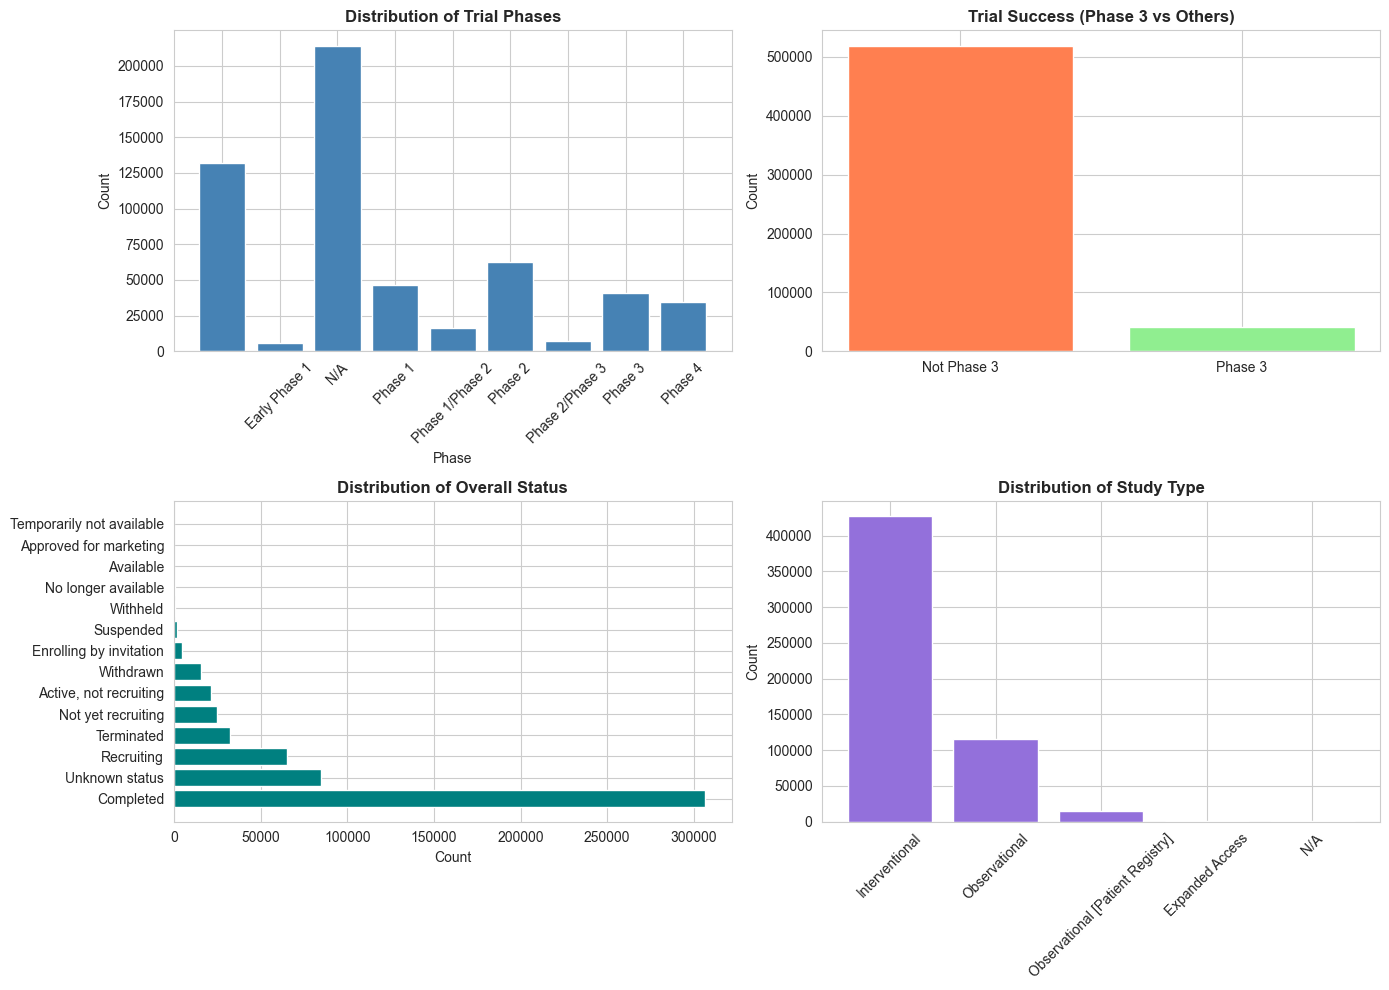


=== Phase Distribution ===
phase
                   132310
Early Phase 1        5941
N/A                214181
Phase 1             46339
Phase 1/Phase 2     16104
Phase 2             62324
Phase 2/Phase 3      7276
Phase 3             40670
Phase 4             34363
Name: count, dtype: int64

Total trials: 559508
Phase 3 trials: 40670
Phase 3 percentage: 7.27%


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Phase distribution
phase_counts = df["phase"].value_counts().sort_index()
axes[0, 0].bar(phase_counts.index, phase_counts.values, color='steelblue')
axes[0, 0].set_title("Distribution of Trial Phases", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Phase")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis='x', rotation=45)

# Success distribution (Phase 3 vs Others)
success_counts = df["success"].value_counts().sort_index()
axes[0, 1].bar(['Not Phase 3', 'Phase 3'], success_counts.values, color=['coral', 'lightgreen'])
axes[0, 1].set_title("Trial Success (Phase 3 vs Others)", fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel("Count")

# Overall Status distribution
status_counts = df["overall_status"].value_counts()
axes[1, 0].barh(status_counts.index, status_counts.values, color='teal')
axes[1, 0].set_title("Distribution of Overall Status", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Count")

# Study Type distribution
study_type_counts = df["study_type"].value_counts()
axes[1, 1].bar(study_type_counts.index, study_type_counts.values, color='mediumpurple')
axes[1, 1].set_title("Distribution of Study Type", fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel("Count")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Phase Distribution ===")
print(phase_counts)
print(f"\nTotal trials: {len(df)}")
print(f"Phase 3 trials: {(df['phase'] == 'Phase 3').sum()}")
print(f"Phase 3 percentage: {(df['phase'] == 'Phase 3').mean()*100:.2f}%")

In [22]:
# Check class balance and missing values
print("=== Class Balance ===")
print(df["success"].value_counts())
print(f"Class distribution: {df['success'].value_counts(normalize=True)}")

# Check missing values in key features
features_to_use = [
    "minimum_age_years",
    "maximum_age_years",
    "enrollment_num",
    "facility_count",
    "conditions_count",
]

print("\n=== Missing Values ===")
print(df[features_to_use + ["success"]].isnull().sum())

# Display basic statistics
print("\n=== Feature Statistics ===")
print(df[features_to_use].describe())

=== Class Balance ===
success
0    518838
1     40670
Name: count, dtype: int64
Class distribution: success
0    0.927311
1    0.072689
Name: proportion, dtype: float64

=== Missing Values ===
minimum_age_years     36985
maximum_age_years    262596
enrollment_num         7052
facility_count            0
conditions_count          0
success                   0
dtype: int64

=== Feature Statistics ===
       minimum_age_years  maximum_age_years  enrollment_num  facility_count  \
count      522523.000000      296912.000000    5.524560e+05   559508.000000   
mean           19.763753          58.558572    5.503299e+03        5.980043   
std            11.150960          26.345358    4.700503e+05       31.437478   
min             0.000000           0.002740    0.000000e+00        0.000000   
25%            18.000000          45.000000    3.000000e+01        1.000000   
50%            18.000000          65.000000    6.900000e+01        1.000000   
75%            18.000000          75.000000  

In [23]:
# Add categorical features
features_numeric = [
    "minimum_age_years",
    "maximum_age_years",
    "enrollment_num",
    "facility_count",
    "conditions_count",
]

# Create a copy of the dataframe with numeric features
X = df[features_numeric + ["overall_status", "study_type"]].copy()

# Add categorical features with one-hot encoding

categorical_features = ['overall_status', 'study_type']
X = pd.get_dummies(X, columns=categorical_features, drop_first=True, prefix=categorical_features)

# Clean feature names to be XGBoost-compatible (remove brackets and angle brackets)
X.columns = [col.replace('[', '').replace(']', '').replace('<', '').replace('>', '') for col in X.columns]

# Get target variable
y = df["success"].copy()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Prepare features and target
X = X.copy()
y = y.copy()

# Drop rows with missing enrollment
print("Before dropping enrollment NaNs:", len(X))
valid_enrollment = X['enrollment_num'].notna()
X = X[valid_enrollment]
y = y[valid_enrollment]
print(f"After dropping enrollment NaNs: {len(X)}")

# Stratified train/test split before imputing ages 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Maintains class distribution
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Class distribution in training set:\n{y_train.value_counts()}")

# Impute missing ages with median from TRAINING SET ONLY
age_cols = ["minimum_age_years", "maximum_age_years"]
for col in age_cols:
    median_val = X_train[col].median()
    print(f"\nMedian {col} (from training set): {median_val}")
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

print(f"\n=== Data After Imputation ===")
print(f"Training set missing values:\n{X_train.isnull().sum()}")
print(f"Test set missing values:\n{X_test.isnull().sum()}")

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures scaled successfully")
print(f"Final training set size: {len(X_train)}")
print(f"Final test set size: {len(X_test)}")

Before dropping enrollment NaNs: 559508
After dropping enrollment NaNs: 552456

Training set size: 441964
Test set size: 110492
Class distribution in training set:
success
0    410002
1     31962
Name: count, dtype: int64

Median minimum_age_years (from training set): 18.0

Median maximum_age_years (from training set): 65.0

=== Data After Imputation ===
Training set missing values:
minimum_age_years                            0
maximum_age_years                            0
enrollment_num                               0
facility_count                               0
conditions_count                             0
overall_status_Approved for marketing        0
overall_status_Available                     0
overall_status_Completed                     0
overall_status_Enrolling by invitation       0
overall_status_No longer available           0
overall_status_Not yet recruiting            0
overall_status_Recruiting                    0
overall_status_Suspended                     0
ove

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# Setup stratified k-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scoring metrics for evaluation
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

print("Stratified K-Fold (5 folds) setup complete")
print(f"This will maintain class distribution across all folds")

Stratified K-Fold (5 folds) setup complete
This will maintain class distribution across all folds


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Setup stratified k-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scoring metrics for evaluation
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

print(f"Metrics: Accuracy, Precision, Recall, F1, ROC-AUC\n")

# 1. Logistic Regression with class balancing
print("Training Logistic Regression with cross-validation...")
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lr_cv_results = cross_validate(
    lr_model, X_train_scaled, y_train, 
    cv=skf, scoring=scoring, return_train_score=True
)

print("=== Logistic Regression Cross-Validation Results ===")
for metric in scoring.keys():
    test_scores = lr_cv_results[f'test_{metric}']
    print(f"{metric.upper()}: {test_scores.mean():.4f} (+/- {test_scores.std():.4f})")

# 2. Random Forest with class balancing
print("\n\nTraining Random Forest with cross-validation...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_cv_results = cross_validate(
    rf_model, X_train, y_train,
    cv=skf, scoring=scoring, return_train_score=True
)

print("=== Random Forest Cross-Validation Results ===")
for metric in scoring.keys():
    test_scores = rf_cv_results[f'test_{metric}']
    print(f"{metric.upper()}: {test_scores.mean():.4f} (+/- {test_scores.std():.4f})")

# 3. XGBoost (with clean feature names)
print("\n\nTraining XGBoost with cross-validation...")
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    verbosity=0
)

xgb_cv_results = cross_validate(
    xgb_model, X_train, y_train,
    cv=skf, scoring=scoring, return_train_score=True
)

print("=== XGBoost Cross-Validation Results ===")
for metric in scoring.keys():
    test_scores = xgb_cv_results[f'test_{metric}']
    print(f"{metric.upper()}: {test_scores.mean():.4f} (+/- {test_scores.std():.4f})")

Metrics: Accuracy, Precision, Recall, F1, ROC-AUC

Training Logistic Regression with cross-validation...
=== Logistic Regression Cross-Validation Results ===
ACCURACY: 0.6161 (+/- 0.0024)
PRECISION: 0.1296 (+/- 0.0007)
RECALL: 0.7538 (+/- 0.0025)
F1: 0.2212 (+/- 0.0011)
ROC_AUC: 0.7819 (+/- 0.0011)


Training Random Forest with cross-validation...
=== Random Forest Cross-Validation Results ===
ACCURACY: 0.8145 (+/- 0.0016)
PRECISION: 0.2383 (+/- 0.0025)
RECALL: 0.7127 (+/- 0.0053)
F1: 0.3572 (+/- 0.0034)
ROC_AUC: 0.8601 (+/- 0.0021)


Training XGBoost with cross-validation...
=== XGBoost Cross-Validation Results ===
ACCURACY: 0.7843 (+/- 0.0004)
PRECISION: 0.2181 (+/- 0.0009)
RECALL: 0.7671 (+/- 0.0045)
F1: 0.3397 (+/- 0.0015)
ROC_AUC: 0.8668 (+/- 0.0018)


In [27]:
from sklearn.ensemble import VotingClassifier

print("Training Soft-Voting Ensemble with cross-validation...")

# Create voting classifier with soft voting (probabilistic)
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )),
        ('rf', RandomForestClassifier(
            n_estimators=100,
            max_depth=15,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )),
        ('xgb', XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
            random_state=42,
            n_jobs=-1,
            tree_method='hist',
            verbosity=0
        ))
    ],
    voting='soft'
)

voting_cv_results = cross_validate(
    voting_clf, X_train, y_train,
    cv=skf, scoring=scoring, return_train_score=True
)

print("=== Soft-Voting Ensemble Cross-Validation Results ===")
for metric in scoring.keys():
    test_scores = voting_cv_results[f'test_{metric}']
    print(f"{metric.upper()}: {test_scores.mean():.4f} (+/- {test_scores.std():.4f})")

Training Soft-Voting Ensemble with cross-validation...


/Users/andrewjin/Documents/GitHub/aipi520-project2/myenv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/andrewjin/Documents/GitHub/aipi520-project2/myenv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data 

=== Soft-Voting Ensemble Cross-Validation Results ===
ACCURACY: 0.7978 (+/- 0.0023)
PRECISION: 0.2269 (+/- 0.0026)
RECALL: 0.7460 (+/- 0.0035)
F1: 0.3480 (+/- 0.0033)
ROC_AUC: 0.8632 (+/- 0.0018)


In [28]:
import pandas as pd

# Compile results into comparison table
results_summary = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Soft-Voting Ensemble'],
    'Accuracy': [
        lr_cv_results['test_accuracy'].mean(),
        rf_cv_results['test_accuracy'].mean(),
        xgb_cv_results['test_accuracy'].mean(),
        voting_cv_results['test_accuracy'].mean()
    ],
    'Precision': [
        lr_cv_results['test_precision'].mean(),
        rf_cv_results['test_precision'].mean(),
        xgb_cv_results['test_precision'].mean(),
        voting_cv_results['test_precision'].mean()
    ],
    'Recall': [
        lr_cv_results['test_recall'].mean(),
        rf_cv_results['test_recall'].mean(),
        xgb_cv_results['test_recall'].mean(),
        voting_cv_results['test_recall'].mean()
    ],
    'F1': [
        lr_cv_results['test_f1'].mean(),
        rf_cv_results['test_f1'].mean(),
        xgb_cv_results['test_f1'].mean(),
        voting_cv_results['test_f1'].mean()
    ],
    'ROC-AUC': [
        lr_cv_results['test_roc_auc'].mean(),
        rf_cv_results['test_roc_auc'].mean(),
        xgb_cv_results['test_roc_auc'].mean(),
        voting_cv_results['test_roc_auc'].mean()
    ]
}

comparison_df = pd.DataFrame(results_summary)
print("\n=== Model Comparison (Cross-Validation Averages) ===")
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n=== Best Model per Metric ===")
for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    best_idx = comparison_df[col].idxmax()
    print(f"{col}: {comparison_df.loc[best_idx, 'Model']} ({comparison_df.loc[best_idx, col]:.4f})")


=== Model Comparison (Cross-Validation Averages) ===
               Model  Accuracy  Precision   Recall       F1  ROC-AUC
 Logistic Regression  0.616100   0.129610 0.753801 0.221187 0.781905
       Random Forest  0.814487   0.238325 0.712722 0.357203 0.860073
             XGBoost  0.784329   0.218144 0.767099 0.339688 0.866771
Soft-Voting Ensemble  0.797816   0.226920 0.745980 0.347981 0.863232

=== Best Model per Metric ===
Accuracy: Random Forest (0.8145)
Precision: Random Forest (0.2383)
Recall: XGBoost (0.7671)
F1: Random Forest (0.3572)
ROC-AUC: XGBoost (0.8668)


In [29]:
# Train final models on full training set and evaluate on test set
print("=== Test Set Performance ===\n")

# Logistic Regression
lr_final = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
lr_final.fit(X_train_scaled, y_train)
lr_test_pred = lr_final.predict(X_test_scaled)
lr_test_pred_proba = lr_final.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression:")
print(f"  Accuracy: {accuracy_score(y_test, lr_test_pred):.4f}")
print(f"  Precision: {precision_score(y_test, lr_test_pred):.4f}")
print(f"  Recall: {recall_score(y_test, lr_test_pred):.4f}")
print(f"  F1: {f1_score(y_test, lr_test_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, lr_test_pred_proba):.4f}")

# Random Forest
rf_final = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)
rf_test_pred = rf_final.predict(X_test)
rf_test_pred_proba = rf_final.predict_proba(X_test)[:, 1]

print("\nRandom Forest:")
print(f"  Accuracy: {accuracy_score(y_test, rf_test_pred):.4f}")
print(f"  Precision: {precision_score(y_test, rf_test_pred):.4f}")
print(f"  Recall: {recall_score(y_test, rf_test_pred):.4f}")
print(f"  F1: {f1_score(y_test, rf_test_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, rf_test_pred_proba):.4f}")

# XGBoost
xgb_final = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                          scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
                          random_state=42, n_jobs=-1, tree_method='hist', verbosity=0)
xgb_final.fit(X_train, y_train)
xgb_test_pred = xgb_final.predict(X_test)
xgb_test_pred_proba = xgb_final.predict_proba(X_test)[:, 1]

print("\nXGBoost:")
print(f"  Accuracy: {accuracy_score(y_test, xgb_test_pred):.4f}")
print(f"  Precision: {precision_score(y_test, xgb_test_pred):.4f}")
print(f"  Recall: {recall_score(y_test, xgb_test_pred):.4f}")
print(f"  F1: {f1_score(y_test, xgb_test_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, xgb_test_pred_proba):.4f}")

# Soft-Voting Ensemble
voting_final = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1)),
        ('xgb', XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                             scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
                             random_state=42, n_jobs=-1, tree_method='hist', verbosity=0))
    ],
    voting='soft'
)
voting_final.fit(X_train, y_train)  # Note: X_train not X_train_scaled for ensemble
voting_test_pred = voting_final.predict(X_test)
voting_test_pred_proba = voting_final.predict_proba(X_test)[:, 1]

print("\nSoft-Voting Ensemble:")
print(f"  Accuracy: {accuracy_score(y_test, voting_test_pred):.4f}")
print(f"  Precision: {precision_score(y_test, voting_test_pred):.4f}")
print(f"  Recall: {recall_score(y_test, voting_test_pred):.4f}")
print(f"  F1: {f1_score(y_test, voting_test_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, voting_test_pred_proba):.4f}")

=== Test Set Performance ===

Logistic Regression:
  Accuracy: 0.6185
  Precision: 0.1296
  Recall: 0.7476
  F1: 0.2208
  ROC-AUC: 0.7818

Random Forest:
  Accuracy: 0.8078
  Precision: 0.2309
  Recall: 0.7113
  F1: 0.3487
  ROC-AUC: 0.8579

XGBoost:
  Accuracy: 0.7801
  Precision: 0.2130
  Recall: 0.7571
  F1: 0.3325
  ROC-AUC: 0.8622


/Users/andrewjin/Documents/GitHub/aipi520-project2/myenv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Soft-Voting Ensemble:
  Accuracy: 0.7930
  Precision: 0.2213
  Recall: 0.7390
  F1: 0.3405
  ROC-AUC: 0.8593


BEST MODEL: RANDOM FOREST

=== Classification Report ===
              precision    recall  f1-score   support

 Not Phase 3       0.97      0.82      0.89    102501
     Phase 3       0.23      0.71      0.35      7991

    accuracy                           0.81    110492
   macro avg       0.60      0.76      0.62    110492
weighted avg       0.92      0.81      0.85    110492


=== Confusion Matrix ===
[[83571 18930]
 [ 2307  5684]]

True Negatives:  83,571
False Positives: 18,930
False Negatives: 2,307
True Positives:  5,684


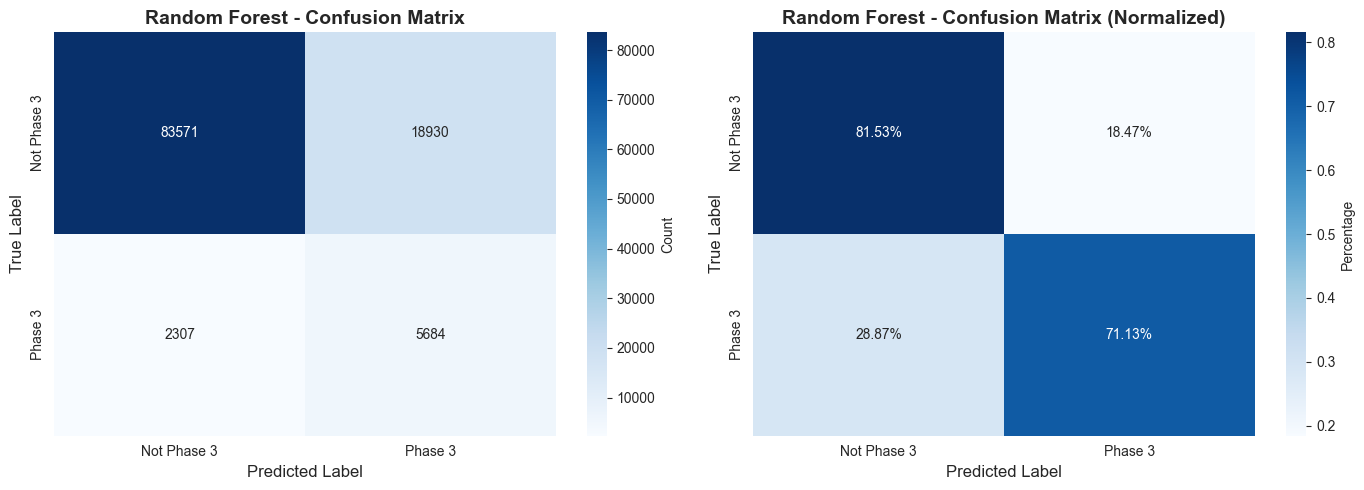

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest is the best model overall
print("=" * 60)
print("BEST MODEL: RANDOM FOREST")
print("=" * 60)

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, rf_test_pred, target_names=['Not Phase 3', 'Phase 3']))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_test_pred)
print("\n=== Confusion Matrix ===")
print(cm)
print(f"\nTrue Negatives:  {cm[0, 0]:,}")
print(f"False Positives: {cm[0, 1]:,}")
print(f"False Negatives: {cm[1, 0]:,}")
print(f"True Positives:  {cm[1, 1]:,}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Phase 3', 'Phase 3'],
            yticklabels=['Not Phase 3', 'Phase 3'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Normalized Confusion Matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Not Phase 3', 'Phase 3'],
            yticklabels=['Not Phase 3', 'Phase 3'],
            cbar_kws={'label': 'Percentage'})
axes[1].set_title('Random Forest - Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

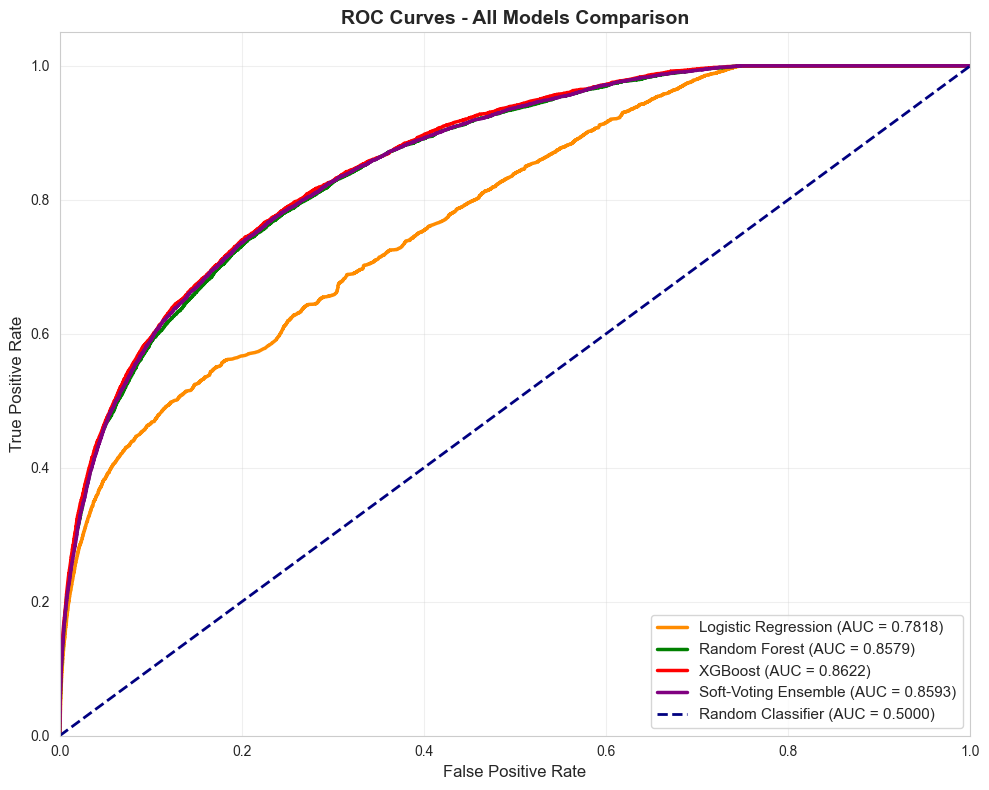


=== ROC-AUC Summary ===
Logistic Regression:   0.7818
Random Forest:         0.8579
XGBoost:               0.8622
Soft-Voting Ensemble:  0.8593


In [32]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curves for all models
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_test_pred_proba)
lr_auc = auc(lr_fpr, lr_tpr)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_test_pred_proba)
rf_auc = auc(rf_fpr, rf_tpr)

xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_test_pred_proba)
xgb_auc = auc(xgb_fpr, xgb_tpr)

voting_fpr, voting_tpr, _ = roc_curve(y_test, voting_test_pred_proba)
voting_auc = auc(voting_fpr, voting_tpr)

# Plot all curves on one figure
plt.figure(figsize=(10, 8))

plt.plot(lr_fpr, lr_tpr, color='darkorange', lw=2.5, label=f'Logistic Regression (AUC = {lr_auc:.4f})')
plt.plot(rf_fpr, rf_tpr, color='green', lw=2.5, label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot(xgb_fpr, xgb_tpr, color='red', lw=2.5, label=f'XGBoost (AUC = {xgb_auc:.4f})')
plt.plot(voting_fpr, voting_tpr, color='purple', lw=2.5, label=f'Soft-Voting Ensemble (AUC = {voting_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
print("\n=== ROC-AUC Summary ===")
print(f"Logistic Regression:   {lr_auc:.4f}")
print(f"Random Forest:         {rf_auc:.4f}")
print(f"XGBoost:               {xgb_auc:.4f}")
print(f"Soft-Voting Ensemble:  {voting_auc:.4f}")